In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\2_chains\3_comp
scenario=3comp_equal  K_MODEL=5  K_TRUE=3
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)
  replication mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids (Full + Chebyshev) ──────────
# Two grids per parameter, used by all cells below; the True DGP only enters the
# envelopes and stays an overlay in the plots.
#   "Full"      - min/max envelope over every component of every sampler + True
#                 DGP; nothing excluded, can be very wide.
#   "Chebyshev" - each model's aggregate mixture mean +/- 5*std; covers >=96% of
#                 its marginal mass for any distribution.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents [Full]:
  Alt1       [-741.00, +605.11]
  Alt2       [-472.27, +599.88]
  Alt3       [-1178.43, +680.22]
  Price      [-247.07, +308.45]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-8.67, +14.36]
  Alt2       [-16.27, +17.28]
  Alt3       [-9.20, +14.12]
  Price      [-19.79, +12.25]


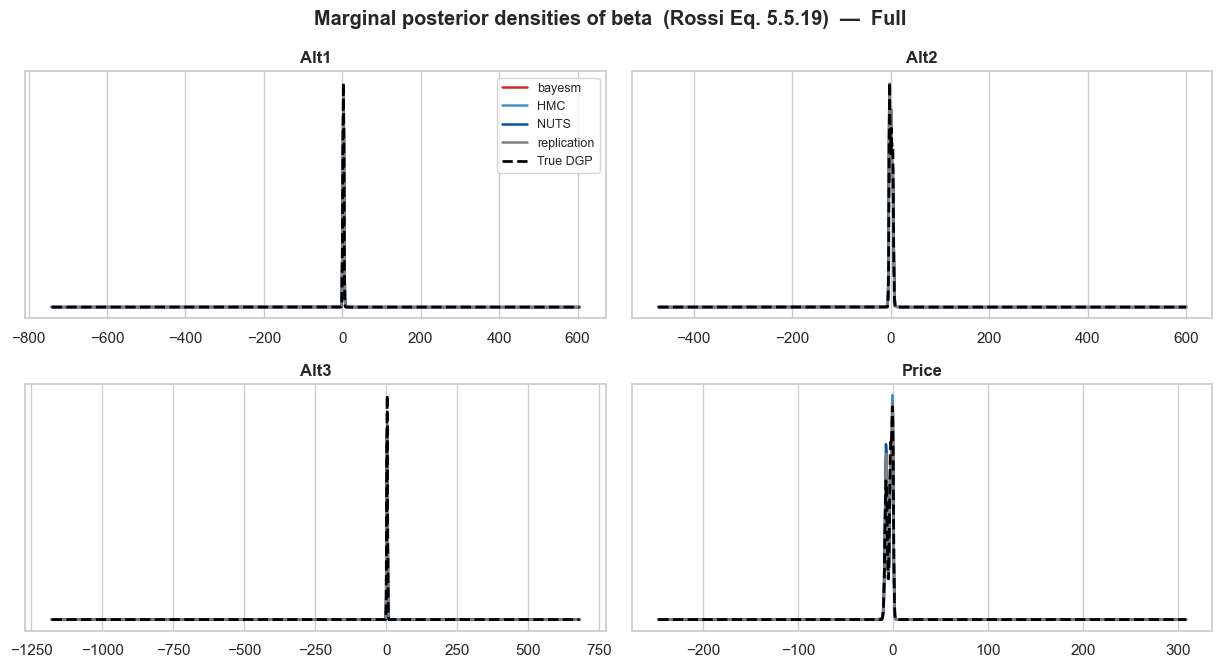

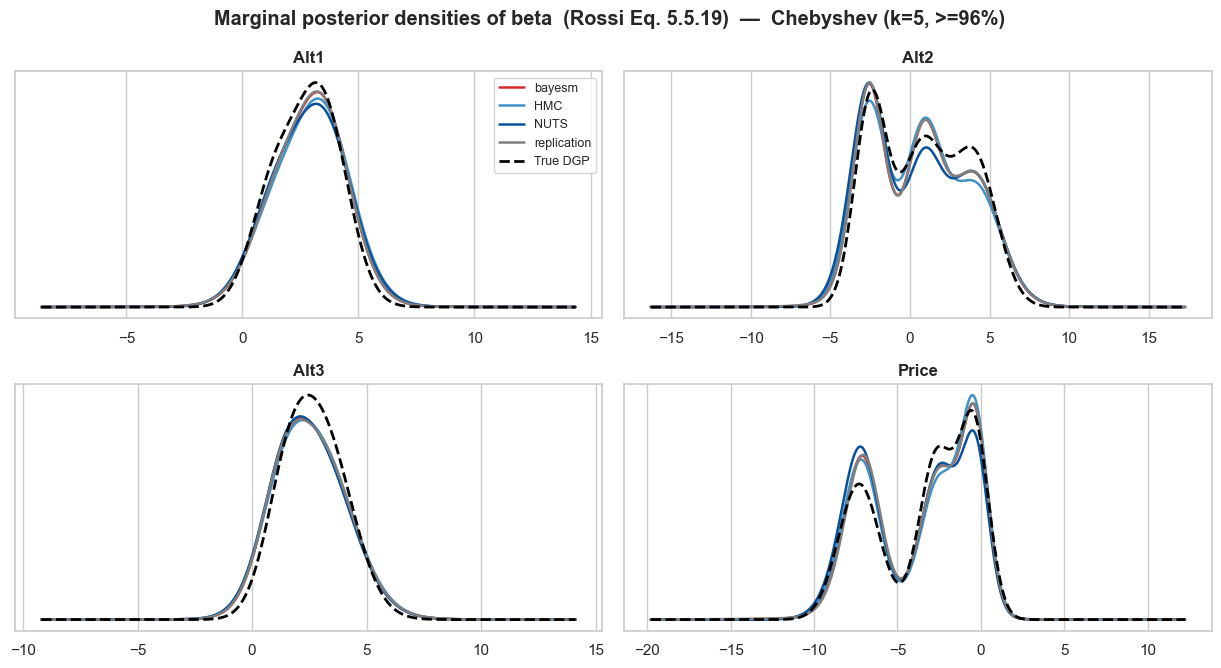

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev ──────────
# One figure per grid pass; True DGP dashed black, bayesm red, Liesel samplers in
# blues. Densities are cached in DENS/DENS_TRUE and reused by Cell 5.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  —  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev ──────────
# Each sampler vs the True DGP only (never sampler-vs-sampler): Hellinger
# (primary), KL(model||true), JSD, TVD, Wasserstein-1. Reuses DENS/DENS_TRUE.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:283: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger   KL      JSD      TVD  Wasserstein1
sampler     param                                                
bayesm      Alt1     0.07241  inf  0.00480  0.04839       0.16919
            Alt2     0.07397  inf  0.00512  0.06245       0.24084
            Alt3     0.07862  inf  0.00585  0.06898       0.20637
            Price    0.05604  inf  0.00291  0.05619       0.17960
HMC         Alt1     0.09570  inf  0.00836  0.06910       0.28013
            Alt2     0.08511  inf  0.00672  0.06892       0.30699
            Alt3     0.08470  inf  0.00669  0.06300       0.22164
            Price    0.05263  inf  0.00260  0.05661       0.17140
NUTS        Alt1     0.09016  inf  0.00734  0.05977       0.24416
            Alt2     0.09418  inf  0.00826  0.07635       0.39569
            Alt3     0.08876  inf  0.00731  0.07690       0.24555
            Price    0.06501  inf  0.00402  0.07736       0.45696
replication Alt1     0.07530  inf  0.00515  0.04856       0.17493
            Alt2     0.07548  inf  0.00523  0.06105       0.23852
            Alt3     0.08045  inf  0.00609  0.06785       0.21335
            Price    0.06689  inf  0.00402  0.06096       0.18746

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.07140  0.04295  0.00470  0.05073       0.16045
            Alt2     0.07367  0.03917  0.00509  0.06378       0.23799
            Alt3     0.07823  0.03862  0.00583  0.07163       0.19441
            Price    0.05548  0.03140  0.00287  0.05650       0.17663
HMC         Alt1     0.09053  0.06318  0.00770  0.07275       0.23190
            Alt2     0.08322  0.05768  0.00650  0.06829       0.28946
            Alt3     0.08312  0.04861  0.00653  0.07155       0.19691
            Price    0.05155  0.03013  0.00252  0.05633       0.16660
NUTS        Alt1     0.08434  0.05870  0.00664  0.06452       0.18372
            Alt2     0.09211  0.06604  0.00799  0.07733       0.37791
            Alt3     0.08595  0.05329  0.00699  0.07755       0.22502
            Price    0.06389  0.04100  0.00392  0.07715       0.45197
replication Alt1     0.07412  0.04792  0.00504  0.05118       0.16517
            Alt2     0.07515  0.04859  0.00519  0.06272       0.23600
            Alt3     0.07977  0.04224  0.00605  0.07269       0.19553
            Price    0.06630  0.05334  0.00396  0.06192       0.18543

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent (analytic in the draws); runs once.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.824,2.899,2.847,2.826,2.719
Alt2,0.623,0.577,0.505,0.628,0.781
Alt3,2.517,2.533,2.461,2.520,2.635
Price,-3.606,-3.576,-3.894,-3.607,-3.454


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.665,4.176,5.302,2.709,2.072
Alt2,9.795,10.354,11.251,9.844,8.600
Alt3,2.725,3.016,5.438,2.787,1.993
Price,9.697,10.020,10.106,9.772,9.352


In [7]:
# ── Cell 7 : Convergence of the Marginals - Goose-identical functional diagnostics ──────────
# az.rhat (rank) / az.ess (bulk, tail) - the exact calls in Goose's summary() -
# on grid-free functionals of each per-draw marginal: mean, sd, q05/q50/q95.
# ESS/s divides by the fit's total wall-clock (meta.json duration_s, incl.
# warmup). Read ESS only where R-hat ~ 1. Alternatives: mc.curve_diagnostics,
# mc.density_series_diagnostics.
if CHAINS == 1:
    print("NOTE: single chain -> split-chain diagnostics; WITHIN-chain checks only.\n")

for m in models:
    rt = m.get("duration_s")
    print(f"--- {m['name']}" + (f"  (fit wall-clock: {rt:,.0f}s)" if rt else "") + " ---")
    display(mc.functional_diagnostics(m, param_names).round(3))

--- bayesm  (fit wall-clock: 433s) ---


Rhat  ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                    
Alt1  mean        1.004   760.917   2666.071       1.757       6.157
      sd          1.005   983.532   3192.009       2.271       7.372
      q05         1.001  1541.742   3629.791       3.561       8.383
      q50         1.004   980.866   3034.452       2.265       7.008
      q95         1.007   628.745   1710.421       1.452       3.950
Alt2  mean        1.001  1245.020   4793.153       2.875      11.070
      sd          1.002   700.812    986.626       1.619       2.279
      q05         1.009   274.791    160.830       0.635       0.371
      q50         1.001   973.254   2304.770       2.248       5.323
      q95         1.001   739.409   1385.028       1.708       3.199
Alt3  mean        1.001  1199.122   3901.840       2.769       9.011
      sd          1.001  1114.392   2816.126       2.574       6.504
      q05         1.001  2022.872   4763.700       4.672      11.002
      q50         1.004   968.118   3641.676       2.236       8.410
      q95         1.001   748.020   1788.633       1.728       4.131
Price mean        1.005   667.832   1559.324       1.542       3.601
      sd          1.018   160.274    129.279       0.370       0.299
      q05         1.019   128.416     81.332       0.297       0.188
      q50         1.000  6097.803  13941.827      14.083      32.198
      q95         1.000  8673.051  14401.397      20.030      33.260

--- HMC  (fit wall-clock: 440s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.027   123.963   238.590       0.282       0.542
      sd          1.194     7.784    55.244       0.018       0.125
      q05         1.021   617.303  2714.911       1.402       6.167
      q50         1.054    30.043   622.852       0.068       1.415
      q95         1.001   401.596   917.332       0.912       2.084
Alt2  mean        1.072    23.172    45.648       0.053       0.104
      sd          1.206     6.907    51.809       0.016       0.118
      q05         1.015   329.364  1149.511       0.748       2.611
      q50         1.020   337.981   570.969       0.768       1.297
      q95         1.039   194.689   760.810       0.442       1.728
Alt3  mean        1.009   622.841  1751.274       1.415       3.978
      sd          1.111    14.102   121.661       0.032       0.276
      q05         1.011   679.480  3227.772       1.544       7.333
      q50         1.004   739.844  2433.875       1.681       5.529
      q95         1.015   340.454  1301.270       0.773       2.956
Price mean        1.064    22.863    49.632       0.052       0.113
      sd          1.010   313.981   962.821       0.713       2.187
      q05         1.016   191.023   688.362       0.434       1.564
      q50         1.103    12.658    42.897       0.029       0.097
      q95         1.018   156.128  2422.853       0.355       5.504

--- NUTS  (fit wall-clock: 4,330s) ---


Rhat  ESS_bulk  ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                   
Alt1  mean        1.059    31.976    75.548       0.007       0.017
      sd          1.127    11.157   129.707       0.003       0.030
      q05         1.006  1291.519  2553.446       0.298       0.590
      q50         1.055    31.480   818.914       0.007       0.189
      q95         1.059    31.934   838.433       0.007       0.194
Alt2  mean        1.197     7.246    45.391       0.002       0.010
      sd          1.018   561.241   280.367       0.130       0.065
      q05         1.007   791.265  2233.793       0.183       0.516
      q50         1.350     4.696    72.021       0.001       0.017
      q95         1.001   947.316  2099.895       0.219       0.485
Alt3  mean        1.096    15.198    67.073       0.004       0.015
      sd          1.067    21.419   123.684       0.005       0.029
      q05         1.006  1182.145  2309.784       0.273       0.533
      q50         1.175     8.315    97.731       0.002       0.023
      q95         1.045    42.715   996.894       0.010       0.230
Price mean        1.651     3.225    42.947       0.001       0.010
      sd          1.029   138.554   655.933       0.032       0.151
      q05         1.003   521.586  1213.821       0.120       0.280
      q50         1.724     3.056    41.751       0.001       0.010
      q95         1.285     5.246    50.143       0.001       0.012

--- replication  (fit wall-clock: 301s) ---


Rhat   ESS_bulk   ESS_tail  ESS_bulk/s  ESS_tail/s
param functional                                                     
Alt1  mean        1.006    662.551   1313.405       2.202       4.365
      sd          1.005    748.640   1912.315       2.488       6.355
      q05         1.001   1546.856   3544.576       5.141      11.780
      q50         1.003    915.892   2304.972       3.044       7.660
      q95         1.010    258.740    301.897       0.860       1.003
Alt2  mean        1.005    553.123    873.955       1.838       2.904
      sd          1.005    275.161    220.848       0.914       0.734
      q05         1.011    113.623     52.465       0.378       0.174
      q50         1.005    808.074   2224.111       2.686       7.392
      q95         1.004    716.867   1393.519       2.382       4.631
Alt3  mean        1.004    624.867   1421.932       2.077       4.726
      sd          1.011    336.690    205.947       1.119       0.684
      q05         1.004   1623.102   3268.179       5.394      10.861
      q50         1.006    468.022    790.047       1.555       2.626
      q95         1.009    570.819   2195.393       1.897       7.296
Price mean        1.007    191.041    157.895       0.635       0.525
      sd          1.024     89.841     43.092       0.299       0.143
      q05         1.029     78.260     33.797       0.260       0.112
      q50         1.000   4560.206  10884.721      15.155      36.174
      q95         1.000  10116.774  15584.265      33.622      51.792

In [8]:
# ── Cell 8 : Notes ──────────
print("Notes:")
print(" - All quantities are label-invariant: relabeling/ECR would not change them.")
print(" - Grids: 'Full' = unbounded envelope over every component + True DGP;")
print("   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).")
print(" - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail")
print("   ESS) on grid-free functionals of each per-draw marginal.")
print(" - 1-chain runs: chains split into halves - a within-chain check only.")
print("   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).")

Notes:
 - All quantities are label-invariant: relabeling/ECR would not change them.
 - Grids: 'Full' = unbounded envelope over every component + True DGP;
   'Chebyshev (k=5)' = each model's mixture mean +/- 5*std (>=96% mass).
 - Cell 7: Goose-identical arviz diagnostics (rank split-R-hat, bulk/tail
   ESS) on grid-free functionals of each per-draw marginal.
 - 1-chain runs: chains split into halves - a within-chain check only.
   bayesm's seed-based chains are not over-dispersed (weaker R-hat test).
